## 1. Which cuisine usually receives the highest inspection grades?
This analysis examines which cuisine types have the highest percentage of "A" grades to see who maintains the cleanest facilities.

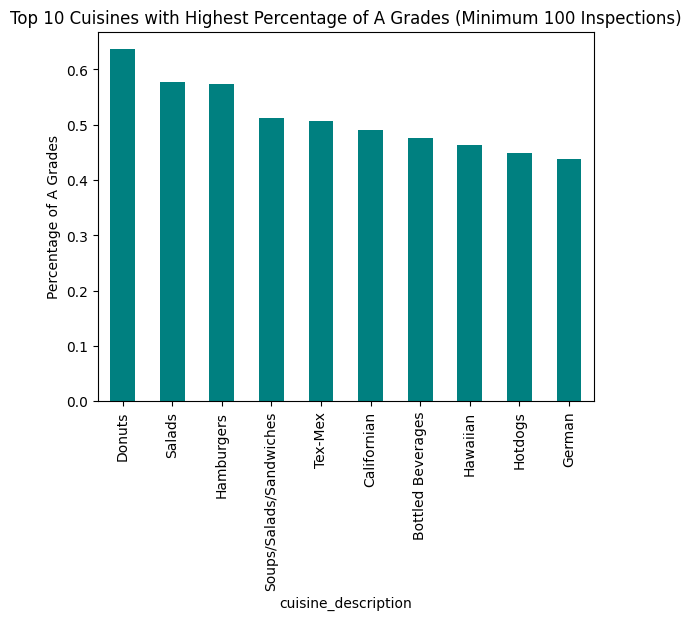

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('cleaned_restaurant_data.csv')

counts = df['cuisine_description'].value_counts()
popular_cuisines = counts[counts > 100].index

cuisine_stats = df[df['cuisine_description'].isin(popular_cuisines)].groupby('cuisine_description')['grade'].apply(lambda x: (x == 'A').mean())
top_10_a_cuisines = cuisine_stats.sort_values(ascending=False).head(10)

top_10_a_cuisines.plot(kind='bar', color='teal')
plt.title('Top 10 Cuisines with Highest Percentage of A Grades (Minimum 100 Inspections)')
plt.ylabel('Percentage of A Grades')
plt.show()

## 2. Is there a correlation between a neighborhood’s borough and its likelihood of not passing a health inspection?
Here, calculations are being performed to find the "failure rate" (percentage of grades that are not "A") for each borough to see if location impacts inspection outcomes.

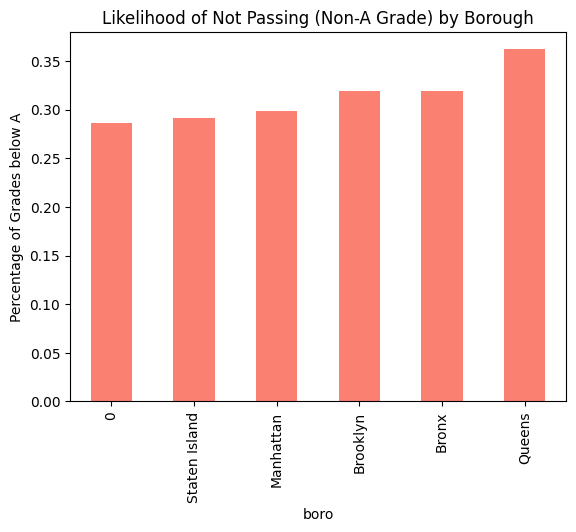

In [2]:
boro_fail_rate = df[df['grade'].notna()].groupby('boro')['grade'].apply(lambda x: (x != 'A').mean())

boro_fail_rate.sort_values().plot(kind='bar', color='salmon')
plt.title('Likelihood of Not Passing (Non-A Grade) by Borough')
plt.ylabel('Percentage of Grades below A')
plt.show()

## 3. Are there hazardous zip codes where the density of violations is far higher than the city average?
This analysis identifies hotspots of violation by identifying zip codes where the number of violations is significantly higher than the city average.

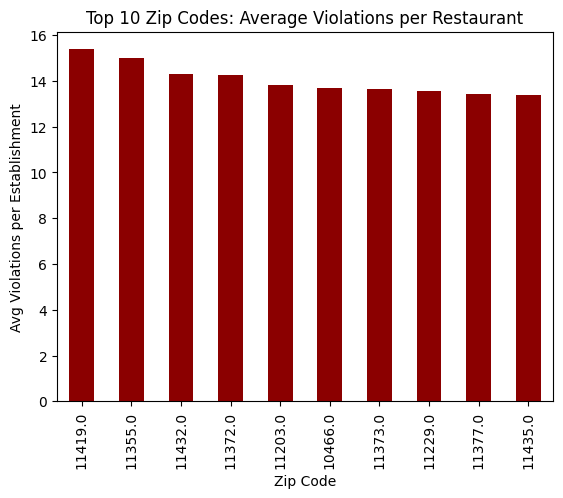

In [3]:
violations_per_zip = df.groupby('zipcode').size()
restaurants_per_zip = df.groupby('zipcode')['camis'].nunique()

meaningful_zips = restaurants_per_zip[restaurants_per_zip > 50].index
normalized_violations = (violations_per_zip / restaurants_per_zip).loc[meaningful_zips]

top_hazardous_zips = normalized_violations.sort_values(ascending=False).head(10)

top_hazardous_zips.plot(kind='bar', color='darkred')
plt.title('Top 10 Zip Codes: Average Violations per Restaurant')
plt.ylabel('Avg Violations per Establishment')
plt.xlabel('Zip Code')
plt.show()

## 4. What are the most common health violations in New York City?
This breakdown shows the top 5 most frequent health violations cited by inspectors across all five boroughs.

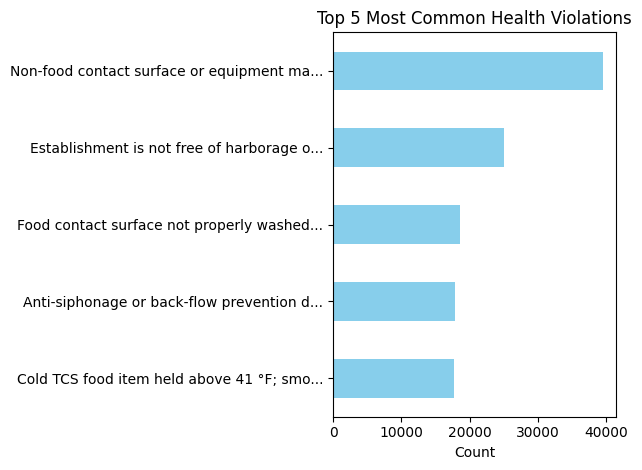

In [4]:
top_violations = df['violation_description'].value_counts().head(5)
top_violations.index = [i[:40] + '...' for i in top_violations.index]

top_violations.plot(kind='barh', color='skyblue')
plt.title('Top 5 Most Common Health Violations')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()